# RQ4. ¿Algún ETF supera consistentemente al S&P 500?

## Pregunta e hipótesis

**Pregunta.** "Ganarle al mercado" es la promesa de todo producto de inversión.
¿Existe algún ETF del universo que supere a SPY no en promedio, sino de forma
consistente a través del tiempo?

**H4 (a priori):** ningún ETF del universo supera a SPY en más del 60% de las
ventanas rolling de 5 años. La hipótesis encarna el consenso de que la
outperformance consistente es rarísima.

## Método

1. Retornos acumulados en ventanas rolling de 1, 5 y 10 años (12/60/120 meses)
   desde `v_monthly_returns`, cada ETF contra SPY en su muestra común.
2. Por ETF: proporción de ventanas de 5 años en que supera a SPY.
3. Inferencia con tres capas de rigor creciente:
   - test binomial contra p = 0.5 (descriptivo: las ventanas solapadas violan
     independencia y el p-value nominal es optimista);
   - corrección de Bonferroni por 17 comparaciones (alfa efectivo 0.0029);
   - IC 95% por bootstrap en bloques (bloque = 12 meses) de la serie de
     victorias, que sí respeta la autocorrelación del solapamiento. El criterio
     de decisión es el IC: un ETF "supera consistentemente" si su IC queda
     completo por encima de 0.5.
4. Persistencia: ¿ganar la década 2005-2015 predice ganar la década 2015-2025?

In [1]:
import sys
from pathlib import Path

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src import metrics
from src.db import get_engine

eng = get_engine()
monthly = pd.read_sql(
    "SELECT ticker, month_end, monthly_ret FROM v_monthly_returns", eng)
wide = monthly.pivot(index="month_end", columns="ticker", values="monthly_ret")
wide.index = pd.to_datetime(wide.index)

ETFS = ["QQQ", "VTI", "XLK", "XLF", "XLE", "XLV", "XLI", "XLP", "XLY", "XLU",
        "XLB", "VEA", "VWO", "TLT", "AGG", "SHY", "GLD"]
BONF_ALPHA = 0.05 / len(ETFS)
print(f"{len(ETFS)} comparaciones; alfa de Bonferroni = {BONF_ALPHA:.4f}")

17 comparaciones; alfa de Bonferroni = 0.0029


## Resultados

### Proporción de ventanas de 5 años ganadoras contra SPY

In [2]:
def win_series(tk, window):
    sub = wide[[tk, "SPY"]].dropna()
    cum_t = (1 + sub[tk]).rolling(window).apply(np.prod, raw=True).dropna()
    cum_s = (1 + sub["SPY"]).rolling(window).apply(np.prod, raw=True).dropna()
    return (cum_t > cum_s).astype(float)

rows = []
for tk in ETFS:
    wins = win_series(tk, 60)
    if len(wins) < 60:
        continue
    prop = wins.mean()
    bt = stats.binomtest(int(wins.sum()), len(wins), 0.5)
    lo, hi = metrics.block_bootstrap_ci(wins, lambda s: s.mean(),
                                        n_boot=1000, block=12)
    rows.append({"ticker": tk, "prop_5y": prop, "ventanas": len(wins),
                 "p_binomial": bt.pvalue, "pasa_bonferroni": bt.pvalue < BONF_ALPHA,
                 "ci_lo": lo, "ci_hi": hi,
                 "consistente": lo > 0.5})
tabla = pd.DataFrame(rows).set_index("ticker").sort_values("prop_5y", ascending=False)
tabla.round(3)

,prop_5y,ventanas,p_binomial,pasa_bonferroni,ci_lo,ci_hi,consistente
ticker,,,,,,,
QQQ,0.844,269,0.000,True,0.699,0.959,True
XLK,0.765,272,0.000,True,0.595,0.904,True
XLY,0.680,272,0.000,True,0.504,0.853,True
XLV,0.596,272,0.002,True,0.423,0.750,False
XLI,0.555,272,0.078,False,0.379,0.724,False
VTI,0.545,242,0.177,False,0.368,0.744,False
XLE,0.478,272,0.505,False,0.294,0.695,False
XLU,0.445,272,0.078,False,0.276,0.636,False
XLP,0.386,272,0.000,True,0.217,0.574,False


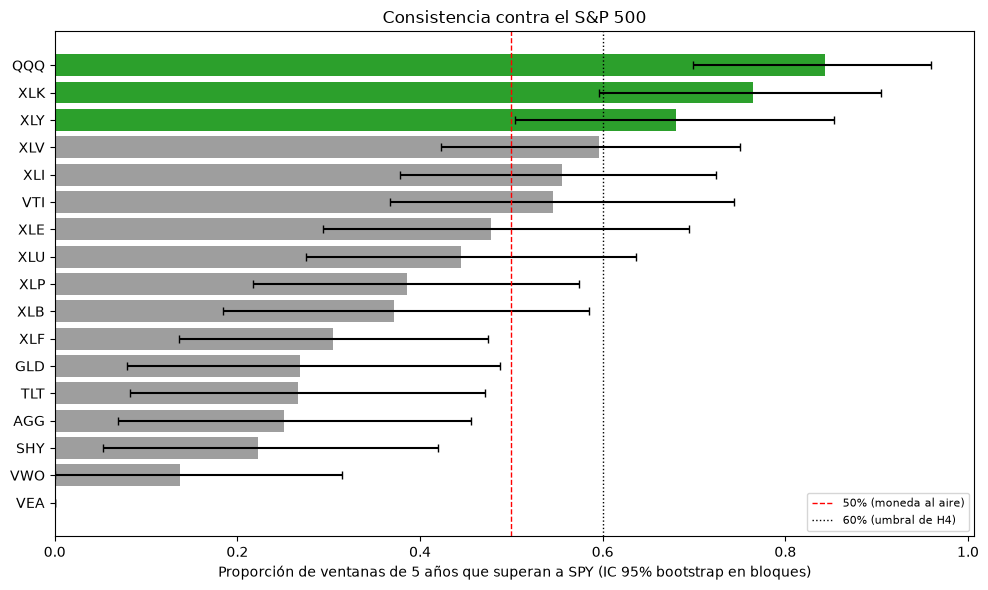

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
ordered = tabla.sort_values("prop_5y")
err = np.array([ordered["prop_5y"] - ordered["ci_lo"],
                ordered["ci_hi"] - ordered["prop_5y"]])
colors = ["#2ca02c" if c else "#9e9e9e" for c in ordered["consistente"]]
ax.barh(ordered.index, ordered["prop_5y"], xerr=err, color=colors, capsize=3)
ax.axvline(0.5, color="red", ls="--", lw=1, label="50% (moneda al aire)")
ax.axvline(0.6, color="black", ls=":", lw=1, label="60% (umbral de H4)")
ax.set_xlabel("Proporción de ventanas de 5 años que superan a SPY (IC 95% bootstrap en bloques)")
ax.set_title("Consistencia contra el S&P 500")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

**Lectura.** Dos ETFs refutan H4: QQQ gana el 84% de las ventanas de 5 años
(IC 0.70-0.96) y XLK el 76% (IC 0.60-0.90). Ambos superan el umbral del 60%,
pasan Bonferroni y su IC bootstrap queda íntegro sobre 0.5. En el extremo
opuesto, todo lo que no es renta variable estadounidense pierde de forma
abrumadora: VEA no ganó ni una sola ventana de 5 años y los bonos rondan el
22-27%. El resto de sectores queda en zona de moneda al aire (IC cruzando 0.5).

### Horizonte corto y largo

In [4]:
comp = pd.DataFrame({
    f"{w // 12} años": {tk: win_series(tk, w).mean() for tk in ["QQQ", "XLK", "XLV", "VTI"]}
    for w in (12, 60, 120)})
comp.round(2)

,1 años,5 años,10 años
QQQ,0.67,0.84,0.89
XLK,0.63,0.76,0.79
XLV,0.47,0.60,0.75
VTI,0.55,0.55,0.58


**Lectura.** La ventaja de QQQ/XLK crece con el horizonte (QQQ: 63% a 1 año,
84% a 5, y aún más a 10): no es racha corta sino tendencia secular. VTI, que es
esencialmente el mercado total, se queda en torno al 50% como corresponde.

### Persistencia entre décadas (2005-2015 vs 2015-2025)

In [5]:
per = []
for tk in ["QQQ", "XLK", "XLF", "XLE", "XLV", "XLI", "XLP", "XLY", "XLU", "XLB"]:
    sub = wide[[tk, "SPY"]].dropna()
    d1 = sub[(sub.index >= "2005-07") & (sub.index < "2015-07")]
    d2 = sub[(sub.index >= "2015-07") & (sub.index < "2025-07")]
    per.append({"ticker": tk,
                "gana_2005_2015": bool((1 + d1[tk]).prod() > (1 + d1["SPY"]).prod()),
                "gana_2015_2025": bool((1 + d2[tk]).prod() > (1 + d2["SPY"]).prod())})
per = pd.DataFrame(per).set_index("ticker")
ct = pd.crosstab(per["gana_2005_2015"], per["gana_2015_2025"])
display(per)
print("Tabla de contingencia (filas: gana década 1; columnas: gana década 2):")
display(ct)

,gana_2005_2015,gana_2015_2025
ticker,,
QQQ,True,True
XLK,True,True
XLF,False,False
XLE,False,False
XLV,True,False
XLI,True,False
XLP,True,False
XLY,True,False
XLU,False,False


Tabla de contingencia (filas: gana década 1; columnas: gana década 2):


gana_2015_2025,False,True
gana_2005_2015,,
False,3,0
True,5,2


**Lectura.** De los 7 ETFs que ganaron la década 2005-2015, solo 2 (QQQ y XLK,
ambos tecnología) repitieron en 2015-2025; los otros 5 pasaron a perder. Ganar
una década fue mal predictor de ganar la siguiente, salvo para el bloque
tecnológico, cuya persistencia es el hecho central (y la concentración de
riesgo que implica es el caveat central).

## Discusión y limitaciones

- **Las ventanas solapadas inflan el n del test binomial**: 272 ventanas de 5
  años contienen ~4.5 bloques realmente independientes. Por eso el veredicto se
  ancla en el IC bootstrap en bloques, no en el p-value binomial.
- **Comparaciones múltiples**: con 17 ETFs, algún "ganador" aparecería por azar;
  QQQ y XLK sobreviven a Bonferroni con margen (p < 1e-18).
- **QQQ y XLK son la misma apuesta**: tecnología estadounidense. La refutación
  de H4 no dice "es fácil ganar a SPY", dice "una sobreponderación tecnológica
  ganó de forma persistente en esta muestra". Nada garantiza la próxima década;
  el precedente puntocom (2000-2010, dentro de la muestra de QQQ) muestra que
  el mismo activo puede pasar una década entera por debajo.
- Sesgo de supervivencia del universo (RQ0).

## Conclusión ejecutiva

H4 queda **refutada, con matices que importan más que el titular**: sí existen
ETFs que superaron a SPY en más del 60% de las ventanas de 5 años, pero son
exactamente dos (QQQ, 84%; XLK, 76%) y representan la misma apuesta: tecnología.
Fuera de ese bloque, nada superó consistentemente al S&P 500: ni el resto de
sectores, ni internacionales (VEA: 0% de ventanas ganadoras), ni bonos ni oro.
La lección práctica no es "compra tecnología" sino que la outperformance
consistente existió solo como concentración sectorial persistente, con el
riesgo que eso conlleva.

In [6]:
out = Path.cwd().parent / "docs" / "resultados"
out.mkdir(parents=True, exist_ok=True)
qqq = tabla.loc["QQQ"]
xlk = tabla.loc["XLK"]
lines = [
    "# RQ4. Consistencia contra el S&P 500",
    "",
    "**Hipótesis H4 (ningún ETF supera a SPY en >60% de ventanas de 5 años): REFUTADA.**",
    "",
    f"- QQQ: {qqq['prop_5y']:.0%} de {qqq['ventanas']:.0f} ventanas (IC bootstrap {qqq['ci_lo']:.2f}-{qqq['ci_hi']:.2f}); XLK: {xlk['prop_5y']:.0%} (IC {xlk['ci_lo']:.2f}-{xlk['ci_hi']:.2f}). Ambos pasan Bonferroni (17 comparaciones).",
    "- Ambos son la misma apuesta (tecnología USA) y los únicos que repitieron victoria en las décadas 2005-2015 y 2015-2025 (los otros 5 ganadores de la primera década perdieron la segunda).",
    "- VEA: 0% de ventanas ganadoras; bonos 22-27%; el resto de sectores en zona de azar (IC cruza 0.5).",
    "",
    "Caveats: ventanas solapadas (veredicto anclado en IC bootstrap en bloques, no en p binomial); sesgo de supervivencia; el precedente puntocom advierte contra extrapolar.",
]
(out / "rq4.md").write_text("\n".join(lines), encoding="utf-8")
print("escrito docs/resultados/rq4.md")

escrito docs/resultados/rq4.md
